In [3]:
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
import os
import io
import numpy as np

In [69]:
# This DataFrame contains all of the event meta data
df = pd.read_csv("data/events.csv", parse_dates=["start_utc"])
ids = df.id.unique()
collumns = df.columns.tolist()
df.head()

,id,img_type,start_utc,llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon,proj,height_m,width_m
0,S778114,ir069,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.94459,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
1,S778114,ir107,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.94459,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
2,S778114,lght,NaT,32.781533,-92.631841,35.94459,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3,S778114,vil,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.94459,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
4,S778114,vis,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.94459,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0


In [71]:
df_reduced = df.copy()
df_reduced = df_reduced.drop(columns=["img_type", "proj", 'llcrnrlon', 
                                      'llcrnrlat', 'urcrnrlon', 'urcrnrlat', 
                                      "height_m", "width_m"])
df_reduced['center_lon'] = (df['llcrnrlon'] + df['urcrnrlon']) / 2
df_reduced['center_lat'] = (df['llcrnrlat'] + df['urcrnrlat']) / 2
df_reduced = df_reduced.drop_duplicates(subset=["id"])
df_reduced.head()

,id,start_utc,center_lon,center_lat
0,S778114,2018-08-20 19:50:00+00:00,-90.382958,34.363062
5,S767475,2018-08-20 21:30:00+00:00,-92.317177,32.656136
10,S771210,2018-08-20 21:40:00+00:00,-113.388288,45.582713
15,S782022,2018-08-21 00:20:00+00:00,-111.000673,32.092002
20,S769788,2018-08-21 17:10:00+00:00,-78.634434,39.703476


### Utility Functions

In [72]:
# this function loads all of the image arrays for a given id
def load_event(id):
    "Load event"
    with h5py.File(f'data/train.h5','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event

In [82]:
id = ids[0]
event = load_event(id)
for img_type in event:
    print(f"{img_type}: {event[img_type].shape} ({event[img_type].dtype})")

print(event["lght"].shape)
print(np.min(event["lght"][:,0]))
print(np.max(event["lght"][:,0]))

vis: (384, 384, 36) (int16)
ir069: (192, 192, 36) (int16)
ir107: (192, 192, 36) (int16)
vil: (384, 384, 36) (uint8)
lght: (38777, 5) (float32)
(38777, 5)
0.0
10799.0


**What would be good to know?**

Is there a data imbalance?
- What is the distribution of number of strikes i.e. is there a large diffence in the number of strikes across events?
- What is the distribution of number of strikes across seasons?
- What is the distribution of number of strikes across time of day?
- What is the distribution of number of strikes across regions?

What does the temporal side of the lightning data look like?
- we know that each frame of an event is 5 mins apart, there are 36 frames in an event, therfore each event is 3 hours long
- what time resolution is are the strikes recorded at?
- what is the distribution of number of strikes across the three hours in/at each seasons, time of day, and regions? (this could be important for feature engineering)


In [28]:
# Strikes per event
no_strikes = []
for id in ids:
    event = load_event(id)
    no_strikes.append(event["lght"].shape[0])

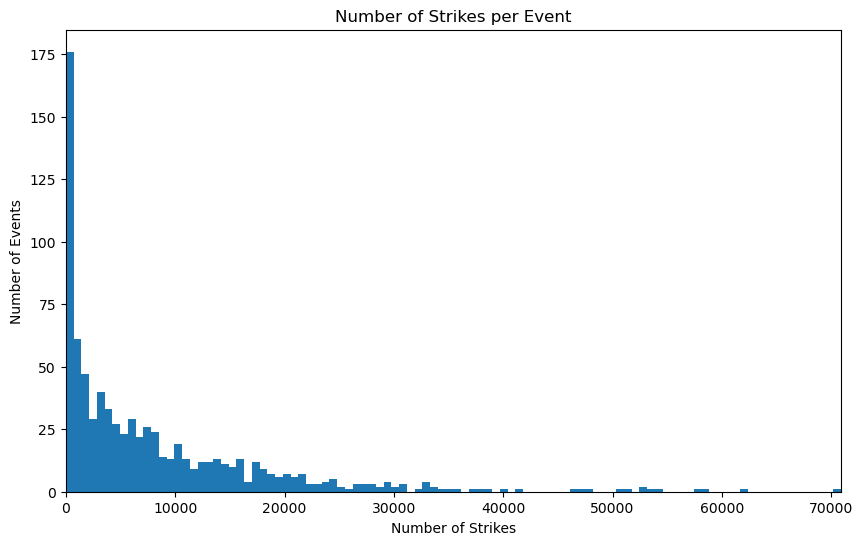

In [48]:
# Plot histogram of number of strikes per event
plt.figure(figsize=(10, 6)) 
plt.hist(no_strikes, bins=100)
plt.title("Number of Strikes per Event")
plt.xlabel("Number of Strikes")
plt.ylabel("Number of Events")
plt.xlim(0, np.max(no_strikes))
plt.show()

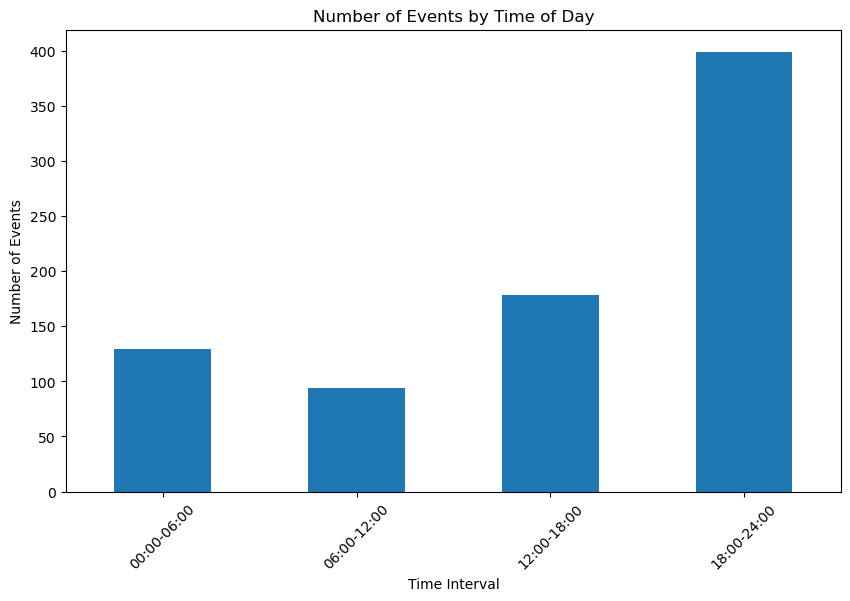

In [73]:
# Step 1: Extract the hour from the datetime column
df_reduced['hour'] = df_reduced['start_utc'].dt.hour

# Step 2: Define the time intervals
bins = [0, 6, 12, 18, 24]
labels = ['00:00-06:00', '06:00-12:00', '12:00-18:00', '18:00-24:00']


# Step 3: Categorize the hours into these intervals
df_reduced['time_interval'] = pd.cut(df_reduced['hour'], bins=bins, labels=labels, right=False)

# Step 4: Plot the histogram
plt.figure(figsize=(10, 6))
df_reduced['time_interval'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Events by Time of Day')
plt.xlabel('Time Interval')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.show()

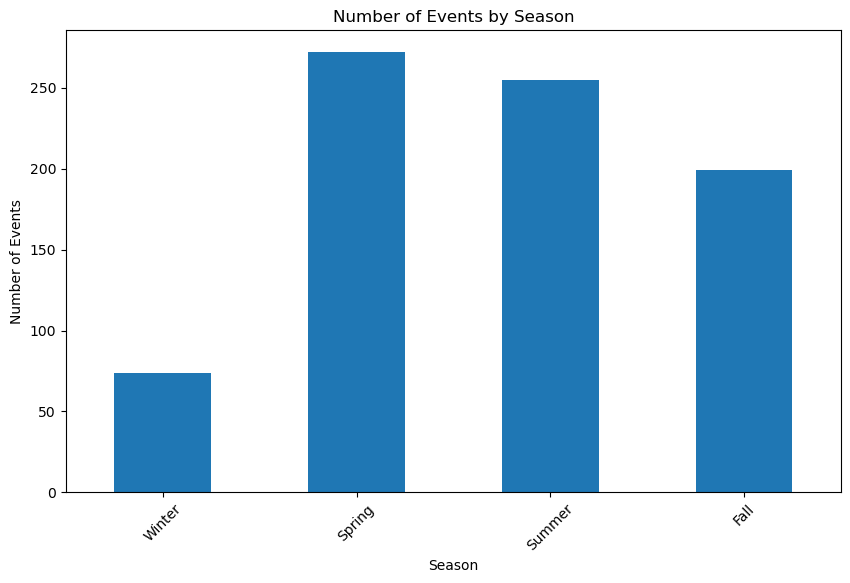

In [74]:
# Step 1: Extract the month from the datetime column
df_reduced['month'] = df_reduced['start_utc'].dt.month

# Adjusted bins to include December in Winter without repeating labels
season_bins = [0, 3, 6, 9, 12]
season_labels = ['Winter', 'Spring', 'Summer', 'Fall']

# Categorize the months into these seasons
df_reduced['season'] = pd.cut(df_reduced['month'] % 12, bins=season_bins, labels=season_labels, right=False, include_lowest=True)

# Step 4: Plot the histogram
plt.figure(figsize=(10, 6))
df_reduced['season'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Events by Season')
plt.xlabel('Season')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.show()

### More appropriate dataframe for EDA 

In [83]:
df_eda = df_reduced.copy()
df_eda.drop(columns=["hour", "month", "start_utc"], inplace=True)
df_eda["strikes"] = no_strikes
df_eda = df_eda.reset_index(drop=True)
df_eda.head(10)

,id,center_lon,center_lat,time_interval,season,strikes
0,S778114,-90.382958,34.363062,18:00-24:00,Summer,38777
1,S767475,-92.317177,32.656136,18:00-24:00,Summer,33131
2,S771210,-113.388288,45.582713,18:00-24:00,Summer,1691
3,S782022,-111.000673,32.092002,00:00-06:00,Summer,7968
4,S769788,-78.634434,39.703476,12:00-18:00,Summer,7695
5,S782134,-82.563975,34.478551,18:00-24:00,Summer,3559
6,S780339,-102.463140,36.654535,18:00-24:00,Summer,14047
7,S780175,-111.087232,39.460434,00:00-06:00,Summer,1754
8,S769599,-76.028278,40.253354,00:00-06:00,Summer,1218
9,S780322,-111.848854,41.929372,12:00-18:00,Summer,2133


In [156]:
# Average number of strikes per season
strikes_per_season = df_eda.groupby('season')['strikes'].mean()
print(strikes_per_season)

season
Winter     2808.202703
Spring    10839.176471
Summer     8900.058824
Fall       5408.170854
Name: strikes, dtype: float64


/tmp/ipykernel_1147907/2012577180.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  strikes_per_season = df_eda.groupby('season')['strikes'].mean()


### Use center longitude and latitude for plotting

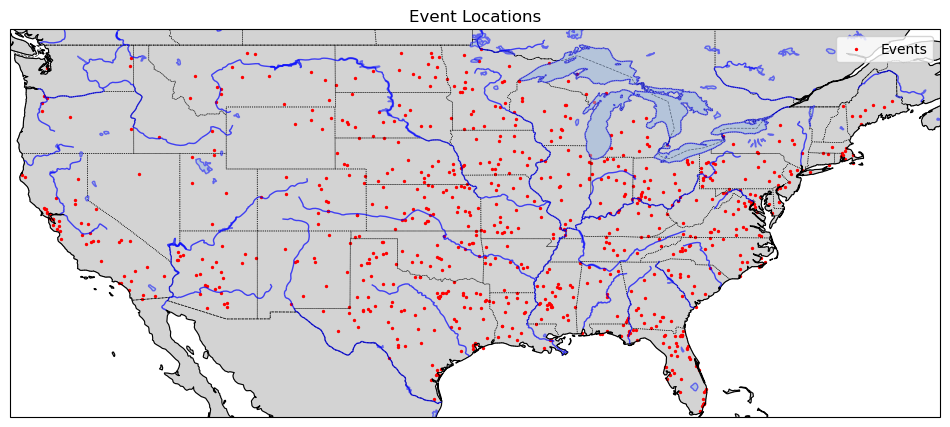

In [79]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a plot with Cartopy
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())  # Use PlateCarree projection for latitude/longitude
ax.set_extent([-125, -65, 25, 50], crs=ccrs.PlateCarree())  # Focus on the US region

# Add map features
ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAKES, edgecolor='blue', alpha=0.5)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', alpha=0.7)

# Plot the lightning event locations
plt.scatter(df_eda["center_lon"], df_eda["center_lat"], s=2, color="red", transform=ccrs.PlateCarree(), label="Events")

# Add title and labels
plt.title("Event Locations")
plt.legend(loc="upper right", fontsize=10)
plt.show()

### Exploring the lightning data 

In order to figure out how we will setup the model target/output we need to understand the data better

**Current issue:** 
- A typicall model maps a fixed size input a know sized output. The problem is that that the number of strikes per frame is not fixed. Therefore the output size must be dynamic?
- Our model **input**: 
    - 3 image channels (64x64x3 after downsampling)
    - 36 frames for a whole event (does one frame influence the next in terms of strike location?)
- Our model **output**: 
    - The locations of n strikes in each frame 
    - is exact time needed? probably not.


**1st Question:** Is there a constant time jump between strikes?

In [151]:
# Lets look at one event first
id = ids[0]
event = load_event(id)
time = event["lght"][:,0]
time_diff = np.diff(time)
print(time_diff)

[ 0.  0.  0. ...  0. 10.  0.]


time_diff
0.0     32904
1.0      5329
10.0      474
11.0       64
2.0         4
9.0         2
Name: count, dtype: int64


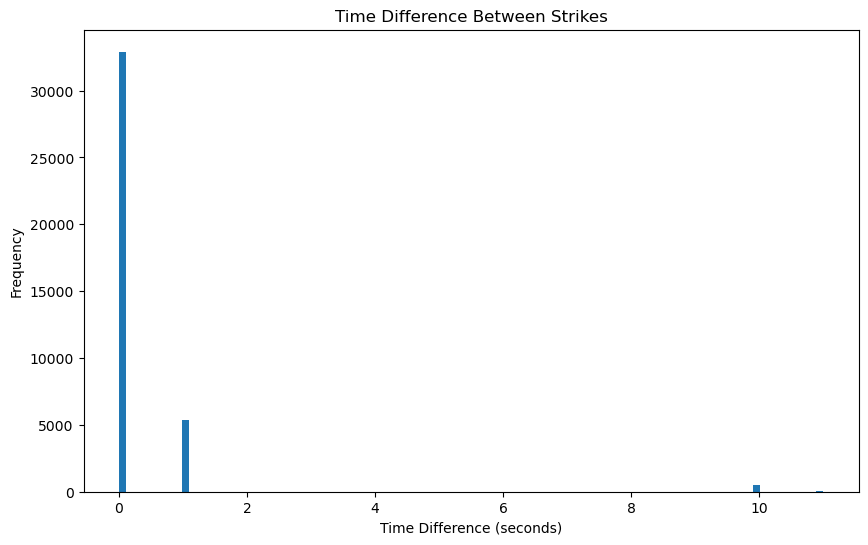

In [152]:
# put into dataframe
strike_df = pd.DataFrame(event["lght"], columns=["time", "lat", "lon", "x", "y"])
strike_df["time_diff"] = np.insert(np.diff(strike_df["time"]), 0, 0)
print(strike_df["time_diff"].value_counts())

# Plot the time difference
plt.figure(figsize=(10, 6))
plt.hist(strike_df["time_diff"], bins=100)
plt.title("Time Difference Between Strikes")
plt.xlabel("Time Difference (seconds)")
plt.ylabel("Frequency")
plt.show()

**Answer:** There is not a constant time jump between strikes however there are many strikes at a constant time.

**Task:** Visualize the number of strikes at a constant time.



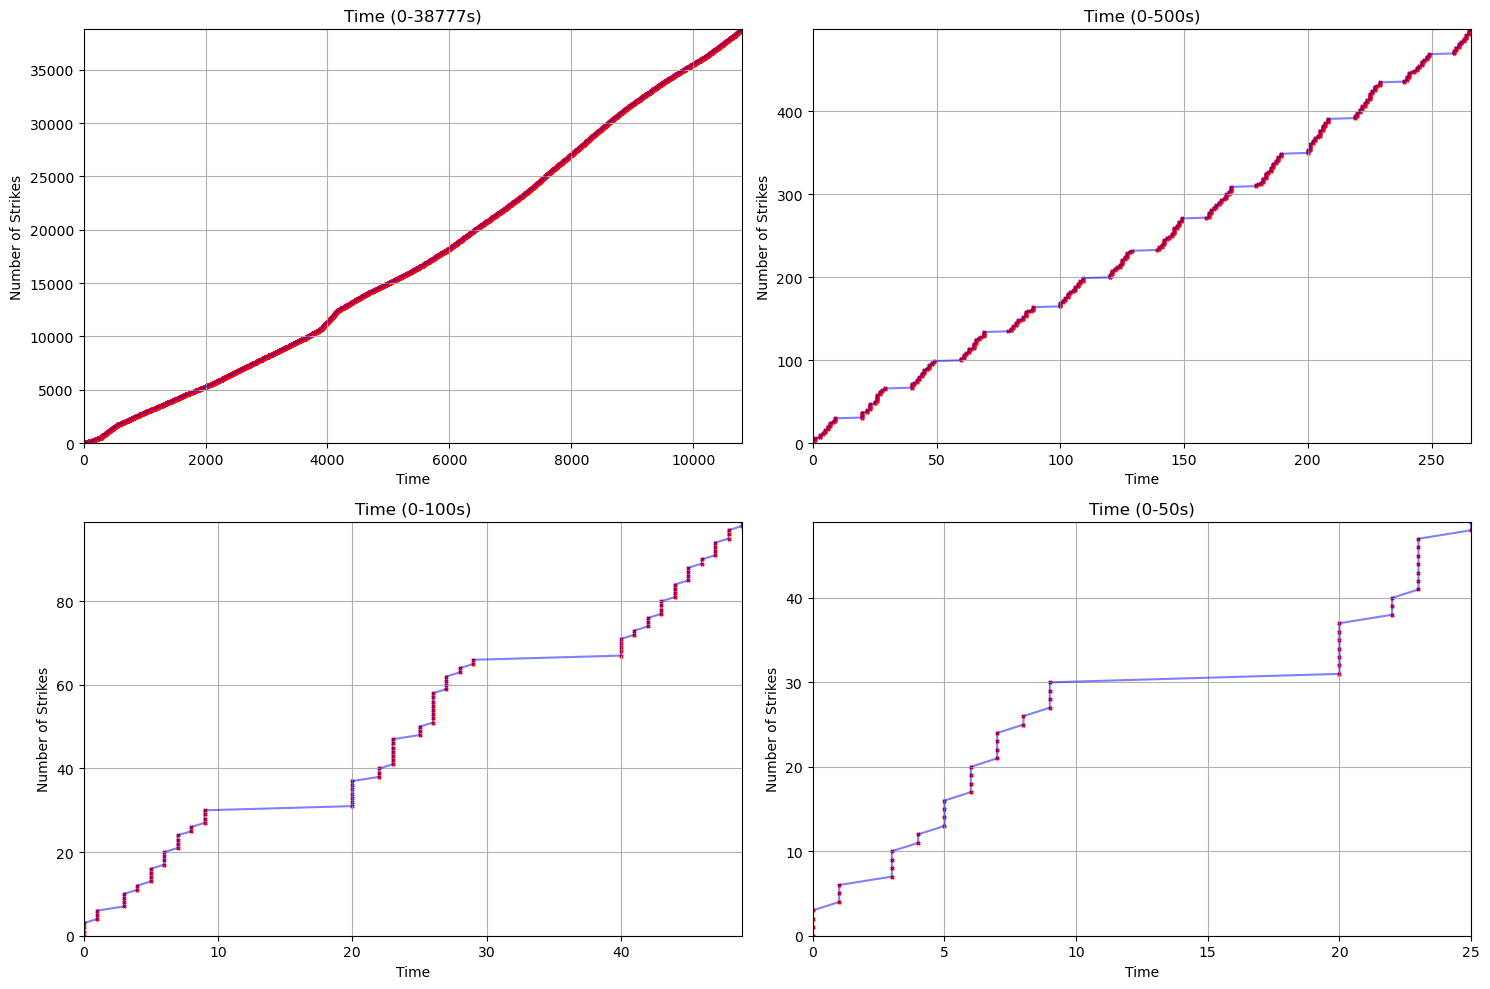

In [153]:
strike_df["cumilative_strikes"] = [i for i in range(strike_df.shape[0])]
# plot number of strikes against time
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

axs = axs.flatten()
n = [len(strike_df["time"]), 500, 100, 50]

for i, n in enumerate(n):
    axs[i].scatter(strike_df["time"][0:n], strike_df["cumilative_strikes"][0:n], s=5, color="red", marker="x")
    axs[i].plot(strike_df["time"][0:n], strike_df["cumilative_strikes"][0:n],'b', alpha=0.5)
    axs[i].set_title(f"Time (0-{n}s)")
    axs[i].grid(True)
    axs[i].set_ylim(0, max(strike_df["cumilative_strikes"][0:n]))
    axs[i].set_xlim(0, max(strike_df["time"][0:n]))
    axs[i].set_xlabel("Time")
    axs[i].set_ylabel("Number of Strikes")


plt.tight_layout()
plt.show()

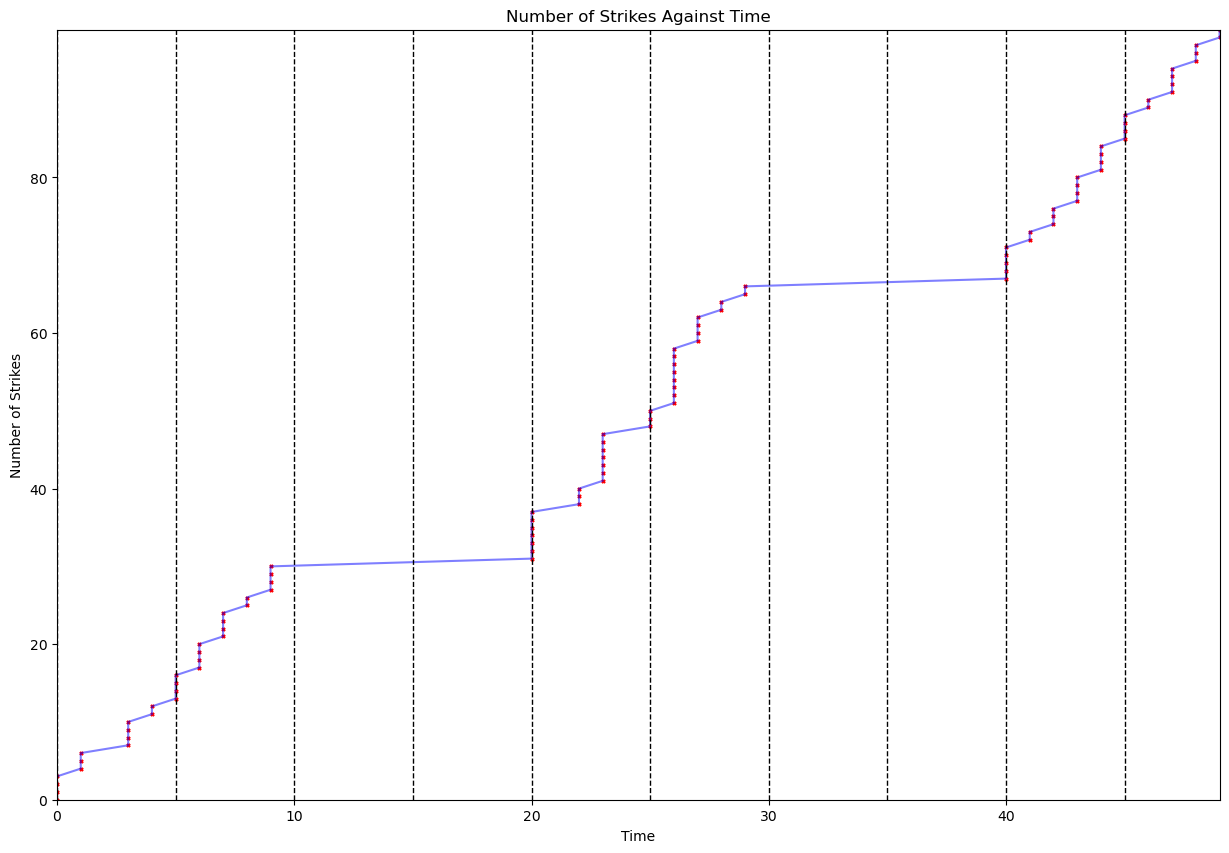

In [154]:
fig, axs = plt.subplots(figsize=(15, 10))
axs.scatter(strike_df["time"][0:100], strike_df["cumilative_strikes"][0:100], s=5, color="red", marker="x")
axs.plot(strike_df["time"][0:100], strike_df["cumilative_strikes"][0:100], 'b', alpha=0.5)
axs.set_title("Number of Strikes Against Time")
axs.set_xlim(0, max(strike_df["time"][0:100]))
axs.set_ylim(0, max(strike_df["cumilative_strikes"][0:100]))
axs.set_xlabel("Time")
axs.set_ylabel("Number of Strikes")

# Add vertical dotted lines every 5 seconds
for sec in range(0, int(max(strike_df["time"][0:100])), 5):
    axs.axvline(x=sec, color='black', linestyle='--', linewidth=1)

plt.show()

In [162]:
event['vil'].shape

(384, 384, 36)